# Packages

In [1]:
import anndata as ad
import squidpy as sq
import pandas as pd
import scanpy as sc
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
# import liana as li
import geopandas as gpd
from matplotlib.widgets import LassoSelector
from shapely.geometry import Polygon
import ipympl 
%matplotlib widget
import matplotlib
import spatialdata as spd
from spatialdata.transformations import get_transformation # to get scale factors and offsets for shapes → image pixel mapping
from shapely.affinity import scale as shapely_scale, translate # shapes management
import geopandas as gpd # for handling shapes as geodataframes
import scipy.sparse as sp

In [2]:
from shapely.affinity import scale as shapely_scale, translate # shapes management

# Data Prep

## Locations

### Gemini

In [23]:
# proj_folder   = Path("/coh_labs/yunroseli/Jona/CAR-T/") # Most up to date files
# zarr_file     = proj_folder / "data/zarr/CellCharterClusters_c2l_annotated"

zarr_file     = "/coh_labs/yunroseli/Jona/CAR-T/data/zarr/fullDataset/processing_Zarr/1_C2l_annotations_400"

code_folder   = Path("/home/janzules/spatial/CAR-T/code")
hallmark_file = code_folder / "references/Mouse_Hallmark.gmt"

### Laptop

In [3]:
# # Directories
# project_dir = Path("/Users/janzules/Roselab/Spatial/CAR_T")
# data_dir    = project_dir / "data"
# results_dir = project_dir / "results"
# figures_dir = project_dir / "figures"
# # Files
# hallmark_file  = project_dir / "code/references/Mouse_Hallmark.gmt"
# zarr_file      = data_dir / "zarrFiles/CellCharterClusters"

## Loading Data

In [24]:
#Reading in files

sdata = spd.read_zarr(zarr_file)
adata = sdata.tables['segmentation_counts']

In [25]:
adata.obsm

AxisArrays with keys: spatial, c2l_q95, c2l_q05, c2l_means

# Functions

In [27]:
def read_gmt(gmt_path):
    gene_sets = {}
    rows = []
    with open(gmt_path, "r") as f:
        for line in f:
            parts = line.rstrip("\n").split("\t")
            if len(parts) < 3:
                continue
            gene_set    = parts[0]
            description = parts[1]
            genes       = parts[2:]
            gene_sets[gene_set] = genes
            rows.append({
                "gene_set":    gene_set,
                "description": description,
                "n_genes":     len(genes),
                "source_file": Path(gmt_path).name,
            })
    return gene_sets, pd.DataFrame(rows)


In [ ]:
pathway_dir = project_dir / "data/references/pathways"

gmt_files = {
    "hallmark": pathway_dir / "mh.all.v2026.1.Mm.symbols.gmt",
    "reactome": pathway_dir / "m2.cp.reactome.v2026.1.Mm.symbols.gmt",
    "go_bp":    pathway_dir / "m5.go.bp.v2026.1.Mm.symbols.gmt",
    "curated":  pathway_dir / "m2.cp.v2026.1.Mm.symbols.gmt",
}

all_gene_sets = {}
gene_set_metadata_list = []

for collection, path in gmt_files.items():
    gs, meta = read_gmt(path)
    meta["collection"] = collection
    all_gene_sets.update(gs)
    gene_set_metadata_list.append(meta)

gene_set_metadata = pd.concat(gene_set_metadata_list, ignore_index=True)
print(f"Total gene sets loaded: {len(all_gene_sets):,}")
display(gene_set_metadata.groupby("collection")[["gene_set"]].count())


In [28]:
# Scoring Pathways of interest

def pathway_scoring(adata, pathways_path, pathways_of_interest):
    # loading pathways
    pathways = read_gmt(pathways_path)
    
    # Chcking if I named the pathways correctly
    failed_pathways = []
    for pathway_name in pathways_of_interest:
        if pathway_name not in pathways:
            print(f"Warning: Pathway '{pathway_name}' not found in the provided pathways.")
            failed_pathways.append(pathway_name)
            continue
    
        #Scoring pathways
        genes = pathways[pathway_name]
        
        genes_in_data = [gene for gene in genes if gene in adata.var_names]
        if len(genes_in_data) < 10: # the lowest number of genes in these pathways is around 27
            print(f"Warning: Not enough genes from pathway '{pathway_name}' are present in the data for scoring.")
            failed_pathways.append(pathway_name)
            continue
        
        sc.tl.score_genes(adata, 
                          gene_list=genes_in_data, 
                          score_name=pathway_name)
        if failed_pathways:
            print(f"Failed to score the following pathways: {', '.join(failed_pathways)}")

def find_pathway_names(pathways, search_term: list):
    matches = [key for key in pathways.keys() if any(term.lower() in key.lower() for term in search_term)]
    return matches




In [34]:
# For a given tissue, get its transform dynamically

def get_tissue_transform(sdata, tissue_name):
    """Returns (scale, tx, ty) for this tissue's shapes → image pixel mapping."""
    shapes_key = f"{tissue_name}_cell_boundaries"
    image_key  = f"{tissue_name}_hires_tissue_image"
    cs = "downscale_to_hires"

    # Scale comes from the shapes transform (a Scale object)
    shapes_tf = get_transformation(sdata.shapes[shapes_key], get_all=True)[cs]
    scale = float(shapes_tf.scale[0])

    # tx, ty come from the image transform (a Sequence → Translation first)
    image_tf = get_transformation(sdata.images[image_key], get_all=True)[cs]
    translation = image_tf.transformations[0].translation  # (c, y, x)
    ty = float(translation[1])
    tx = float(translation[2])

    return scale, tx, ty


In [35]:
def plot_ora_results(
    ora_results,
    cell_type,
    top_n=15,
    exclude=None,
    include=None,
    score_col="Adjusted P-value",
    figsize=(10, 6),
    title=None,
):
    """
    Visualize top ORA pathways for a given cell type.

    Parameters
    ----------
    ora_results : dict  — output from the gseapy enrichr loop
    cell_type   : str   — key in ora_results (e.g. 'Classical_Mono')
    top_n       : int   — number of top pathways to show
    exclude     : list  — pathway terms to drop regardless of rank
    include     : list  — pathway terms to force-add even if outside top N
    score_col   : str   — 'Adjusted P-value' or 'Combined Score'
    """
    if cell_type not in ora_results:
        raise KeyError(f"'{cell_type}' not found. Available: {list(ora_results.keys())}")

    df = ora_results[cell_type].copy()

    # Keep significant hits only
    df = df[df["Adjusted P-value"] < 0.05]

    # Drop excluded terms
    if exclude:
        df = df[~df["Term"].isin(exclude)]

    if df.empty:
        print(f"No significant pathways remaining for {cell_type}")
        return

    # Sort for ranking
    if score_col == "Adjusted P-value":
        df = df.sort_values("Adjusted P-value")
    else:
        df = df.sort_values("Combined Score", ascending=False)

    # Top N selection
    top_df = df.head(top_n)

    # Force-include terms outside top N
    if include:
        missing = [t for t in include if t not in top_df["Term"].values]
        extra_df = df[df["Term"].isin(missing)]
        not_found = [t for t in missing if t not in df["Term"].values]
        if not_found:
            print(f"Warning: these include terms were not found (or not significant): {not_found}")
        top_df = pd.concat([top_df, extra_df]).drop_duplicates(subset="Term")

    # Compute plot values
    if score_col == "Adjusted P-value":
        top_df = top_df.copy()
        top_df["plot_value"] = -np.log10(top_df["Adjusted P-value"])
        xlabel = "-log10(Adjusted P-value)"
    else:
        top_df = top_df.copy()
        top_df["plot_value"] = top_df["Combined Score"]
        xlabel = "Combined Score"

    # Color by database
    db_colors = {
        "KEGG_2019_Mouse":              "#e6550d",
        "GO_Biological_Process_2023":   "#3182bd",
        "GO_Molecular_Function_2023":   "#31a354",
    }
    bar_colors = top_df["Gene_set"].map(db_colors).fillna("#999999")

    # Plot
    fig, ax = plt.subplots(figsize=figsize)
    y_pos = np.arange(len(top_df))

    ax.barh(y_pos, top_df["plot_value"], color=bar_colors, edgecolor="white", linewidth=0.5)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(top_df["Term"], fontsize=10)
    ax.invert_yaxis()
    ax.set_xlabel(xlabel, fontsize=11)
    ax.set_title(title or f"{cell_type} — top {len(top_df)} enriched pathways", fontsize=13)

    # Significance line (only for p-value mode)
    if score_col == "Adjusted P-value":
        ax.axvline(-np.log10(0.05), color="grey", linestyle="--", linewidth=1)

    # Database legend
    handles = [
        plt.Rectangle((0, 0), 1, 1, color=c, label=db)
        for db, c in db_colors.items()
        if db in top_df["Gene_set"].values
    ]
    ax.legend(handles=handles, loc="lower right", fontsize=9, frameon=True)

    plt.tight_layout()
    plt.show()
    return fig, ax


In [31]:
from matplotlib.widgets import RectangleSelector
from matplotlib.path import Path as MplPath





def onselect(eclick, erelease):
    x0, x1 = sorted([eclick.xdata, erelease.xdata])
    y0, y1 = sorted([eclick.ydata, erelease.ydata])
    sel = (
        (coords_shared[:, 0] >= x0) & (coords_shared[:, 0] <= x1) &
        (coords_shared[:, 1] >= y0) & (coords_shared[:, 1] <= y1)
    )
    state["sel"][:] = sel
    status.set_text(f"Selected: {sel.sum()} cells")
    fig.canvas.draw_idle()

# rect = RectangleSelector(
#     ax, onselect,
#     button=[1], interactive=True, useblit=False,
#     props=dict(edgecolor="yellow", facecolor="none", linewidth=2)
# )


## Testing functions

# Scoring + Annotating

In [32]:
# --- Pathway panel ---
# Left  = your short name (becomes the score column: short_name + "_score")
# Right = exact MSigDB gene set name (search gene_set_metadata["gene_set"] to find it)
pathway_panel = {
    "IFN_gamma":  "HALLMARK_INTERFERON_GAMMA_RESPONSE",
    "Glycolysis": "HALLMARK_GLYCOLYSIS",
    # add more below, e.g.:
    # "NK_Degranulation": "GOBP_NATURAL_KILLER_CELL_DEGRANULATION",
}

# --- Validation: confirms every entry exists in all_gene_sets ---
panel_check = []
for short_name, gene_set_name in pathway_panel.items():
    found = gene_set_name in all_gene_sets
    panel_check.append({
        "short_name":    short_name,
        "gene_set_name": gene_set_name,
        "found":         found,
        "n_genes":       len(all_gene_sets[gene_set_name]) if found else np.nan,
        "collection":    gene_set_metadata.loc[
                             gene_set_metadata["gene_set"].eq(gene_set_name), "collection"
                         ].iloc[0] if found else "NOT FOUND",
    })

display(pd.DataFrame(panel_check))


In [ ]:
# --- Score each pathway in the panel ---
available_genes = set(adata.var_names.astype(str))
score_records   = []

for short_name, gene_set_name in pathway_panel.items():
    pathway_genes = all_gene_sets.get(gene_set_name, [])
    matched       = [g for g in pathway_genes if g in available_genes]
    score_col     = f"{short_name}_score"

    print(f"Scoring {short_name!r}  ({len(matched)}/{len(pathway_genes)} genes matched)...")

    if len(matched) < 5:
        print(f"  WARNING: too few matched genes — skipping.")
        continue

    sc.tl.score_genes(adata, gene_list=matched, score_name=score_col, use_raw=False)
    score_records.append({"short_name": short_name, "score_col": score_col, "n_matched": len(matched)})

print("\nDone. Score columns added to adata.obs:")
display(pd.DataFrame(score_records))
# Use these column names in the visualization cells below:
#   pathway_score = "IFN_gamma_score"
#   pathway_score = "Glycolysis_score"


In [10]:
# Copy existing annotations into new column
adata.obs["c2l_winner_spp1"] = adata.obs["c2l_winner"].copy()

# Get Spp1 expression (handles sparse and dense)
spp1_expr = adata[:, "Spp1"].X
if sp.issparse(spp1_expr):
    spp1_expr = spp1_expr.toarray().ravel()
else:
    spp1_expr = np.asarray(spp1_expr).ravel()

# Mask: macrophage AND Spp1 > 0
mac_mask  = adata.obs["c2l_winner"].isin(["M1_like_Mac", "M2_like_Mac"])
spp1_mask = spp1_expr > 0
combined  = mac_mask & spp1_mask

adata.obs.loc[combined, "c2l_winner_spp1"] = "Spp1_Mac"

print(f"Spp1_Mac cells: {combined.sum()}")
print(adata.obs["c2l_winner_spp1"].value_counts())

Spp1_Mac cells: 15944
c2l_winner_spp1
Unknown              239346
Cancer_cell           76636
N2_like_Neu           22672
Spp1_Mac              15944
Erythrocyte           13881
Fibroblast            13700
Classical_Mono        10451
N1_like_Neu           10168
Endothelial            6076
NK                     4505
CD8_T                  3421
M2_like_Mac            2432
B                      2379
cDC                    1664
M1_like_Mac            1258
CD4_T                   380
Intermediate_Mac        296
Nonclassical_Mono       225
pDC                     171
NKT                     165
Treg                     89
Name: count, dtype: int64


# Visualizing pathways

## Single Pathway

Showing 6986 / 27944 cells (top 25.0%, threshold=0.951)


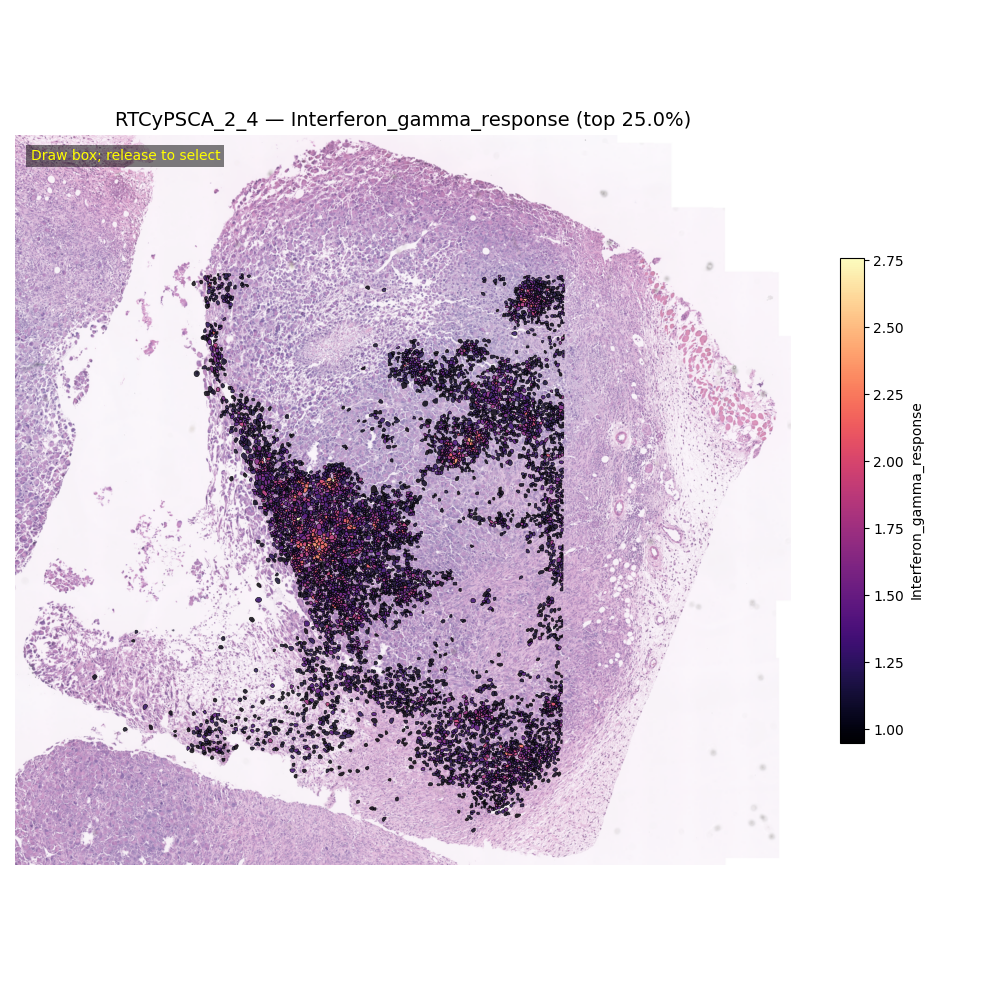

In [86]:
tissue_name   = "RTCyPSCA_2_4"
pathway_score = "Interferon_gamma_response"
# pathway_score = "Glycolysis"
# cmap          = "Greens" #"magma"
cmap          = "magma"
top_quantile  = 0.25    # Top quantile to show     
he_alpha      = 0.8     # H&E image transparency
shrink        = 1       # how much to shrink the polygons

image_key    = f"{tissue_name}_hires_tissue_image"
boundary_key = f"{tissue_name}_cell_boundaries"

image  = sdata.images[image_key].values  # (3, Y, X)
shapes = sdata.shapes[boundary_key].copy()


# -- Different shape conversions ---
#  Convex hull — smooths jagged polygons into a convex shape
# pixels in image space — tune this value
shapes["geometry"] = shapes["geometry"].convex_hull.buffer(-shrink)

# --- Scale factor and translation from the transforms ---
scale, tx, ty = get_tissue_transform(sdata, tissue_name)

# --- Apply scale to polygons ---
shapes["geometry"] = shapes["geometry"].apply(
    lambda geom: shapely_scale(geom, xfact=scale, yfact=scale, origin=(0, 0))
)

# --- Merge scores to shapes df ---

mask  = adata.obs["tissue"] == tissue_name
a_sub = adata[mask]
shapes = shapes.join(a_sub.obs[[pathway_score]], how="left")

state = {"sel": np.zeros(a_sub.n_obs, dtype=bool)}

# --- Centroids for this tissue in shared coordinate space ---
tissue_obs_index = a_sub.obs_names
raw_coords    = adata.obsm["spatial"][adata.obs["tissue"] == tissue_name]
coords_shared = raw_coords * scale   # → shared space (same as axes coords)


# --- Filter to top quantile only ---
threshold = shapes[pathway_score].quantile(1-top_quantile)
shapes_top = shapes[shapes[pathway_score] >= threshold].copy()
print(f"Showing {len(shapes_top)} / {len(shapes)} cells (top {top_quantile*100:.1f}%, threshold={threshold:.3f})")




# --- Plot ---
fig, ax = plt.subplots(figsize=(10, 10))

img_rgb = np.transpose(image, (1, 2, 0))
h, w = img_rgb.shape[:2]
ax.imshow(img_rgb, extent=[tx, tx + w, ty + h, ty], origin="upper", alpha=he_alpha)

shapes_top.plot(
    column=pathway_score,
    cmap=cmap,
    ax=ax,
    alpha=0.8,
    # - outline colors
    edgecolor="black",
    linewidth=0.5,
    legend=True,
    legend_kwds={"label": pathway_score, "shrink": 0.5}
)

ax.set_title(f"{tissue_name} — {pathway_score} (top {top_quantile*100:.1f}%)", fontsize=14)
ax.axis("off")
plt.tight_layout()

# --- Interactive selection ---

status = ax.text(
    0.02, 0.98, "Draw box; release to select",
    transform=ax.transAxes, va="top", color="yellow",
    bbox=dict(facecolor="black", alpha=0.5, pad=3, edgecolor="none")
)

rect = RectangleSelector(
    ax, onselect,
    button=[1], interactive=True, useblit=False,
    props=dict(edgecolor="yellow", facecolor="none", linewidth=2)
)

plt.show()


## Two pathways

Primary  (Interferon_gamma_response ≥ 0.054): 8559 cells
Secondary (Glycolysis):                    25549 cells


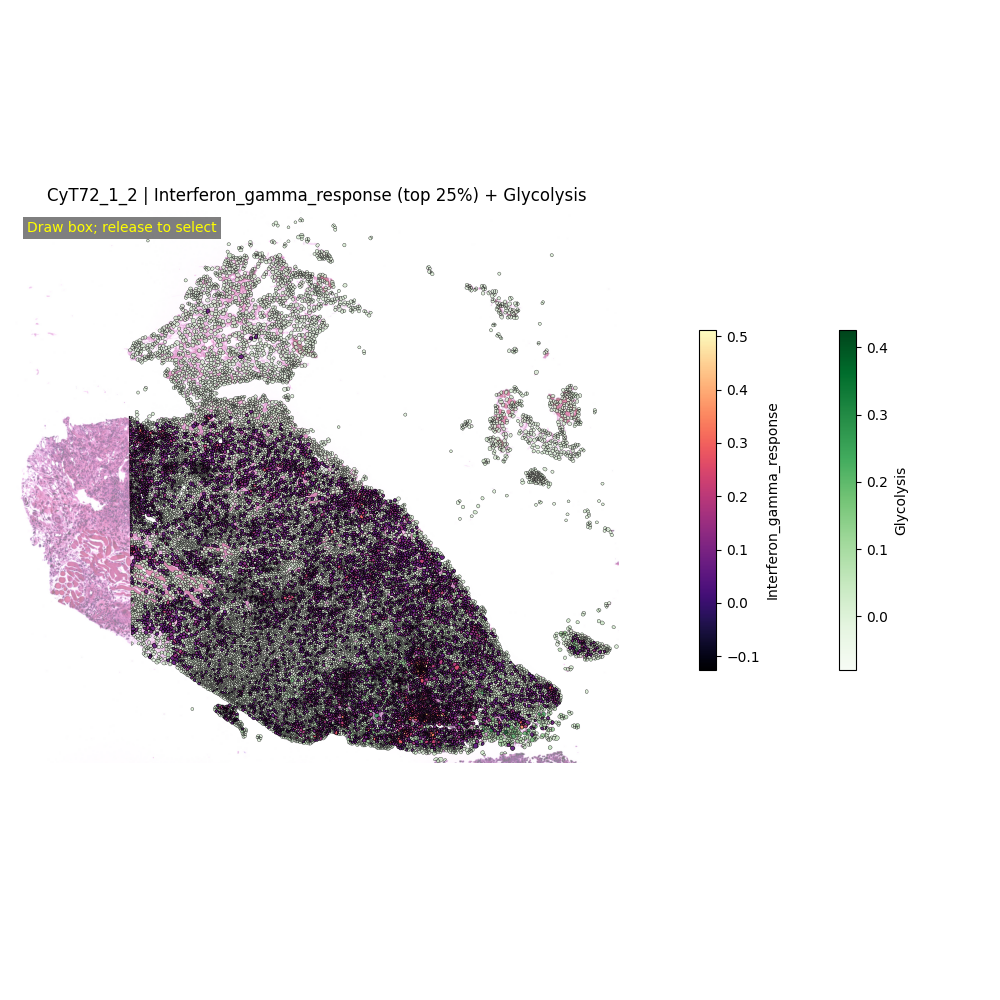

In [44]:
# --- Inputs ---
tissue_name = "CyT72_1_2"
# tissue_name = "CyT72_1_4"
pathway_1   = "Interferon_gamma_response"   # primary - takes precedence
pathway_2   = "Glycolysis"                  # secondary - shown for remaining cells
top_pct_1   = 0.25                          # top 50% of pathway_1 → primary group
cmap_1      = "magma"                       # IFN colormap (default red/orange)
cmap_2      = "Greens"                      # Glycolysis colormap (green range)
he_alpha    = 0.5
shrink      = 1

image_key    = f"{tissue_name}_hires_tissue_image"
boundary_key = f"{tissue_name}_cell_boundaries"

image  = sdata.images[image_key].values
shapes = sdata.shapes[boundary_key].copy()

# --- Shape transformations ---
shapes["geometry"] = shapes["geometry"].convex_hull.buffer(-shrink)
scale, tx, ty = get_tissue_transform(sdata, tissue_name)
shapes["geometry"] = shapes["geometry"].apply(
    lambda geom: shapely_scale(geom, xfact=scale, yfact=scale, origin=(0, 0))
)

# --- Merge both pathway scores onto shapes ---
mask  = adata.obs["tissue"] == tissue_name
a_sub = adata[mask]
shapes = shapes.join(a_sub.obs[[pathway_1, pathway_2]], how="left")
shapes = shapes.dropna(subset=[pathway_1, pathway_2])

# --- Full-range bounds (so highlighted cells stay bright on the colormap) ---
vmin_1, vmax_1 = shapes[pathway_1].min(), shapes[pathway_1].max()

# --- Categorize: primary = top X% of pathway_1, secondary = the rest ---
threshold_1 = shapes[pathway_1].quantile(1 - top_pct_1)
is_primary  = shapes[pathway_1] >= threshold_1

shapes_primary   = shapes[is_primary].copy()
shapes_secondary = shapes[~is_primary].copy()

print(f"Primary  ({pathway_1} ≥ {threshold_1:.3f}): {len(shapes_primary)} cells")
print(f"Secondary ({pathway_2}):                    {len(shapes_secondary)} cells")

# --- Plot ---
plt.close("all")
fig, ax = plt.subplots(figsize=(10, 10))
img_rgb = np.transpose(image, (1, 2, 0))
h, w = img_rgb.shape[:2]
ax.imshow(img_rgb, extent=[tx, tx + w, ty + h, ty], origin="upper", alpha=he_alpha)

# Secondary first (drawn underneath)
shapes_secondary.plot(
    column=pathway_2, cmap=cmap_2, ax=ax,
    alpha=0.8, edgecolor="black", linewidth=0.3,
    legend=True,
    legend_kwds={"label": pathway_2, "shrink": 0.35, "pad": 0.02}
)

# Primary on top — use full-range vmin/vmax so the top-quantile cells stay bright
shapes_primary.plot(
    column=pathway_1, cmap=cmap_1, ax=ax,
    vmin=vmin_1, vmax=vmax_1,
    alpha=0.9, edgecolor="black", linewidth=0.5,
    legend=True,
    legend_kwds={"label": pathway_1, "shrink": 0.35, "pad": 0.10}
)

ax.set_title(
    f"{tissue_name} | {pathway_1} (top {top_pct_1*100:.0f}%) + {pathway_2}",
    fontsize=12,
)
ax.axis("off")
plt.tight_layout()
fig.canvas.toolbar_visible = False
fig.canvas.draw()


from matplotlib.widgets import RectangleSelector

state = {"sel": np.zeros(a_sub.n_obs, dtype=bool)}

raw_coords    = adata.obsm["spatial"][mask.values]
coords_shared = raw_coords * scale
tissue_obs_index = a_sub.obs_names

status = ax.text(
    0.02, 0.98, "Draw box; release to select",
    transform=ax.transAxes, va="top", color="yellow",
    bbox=dict(facecolor="black", alpha=0.5, pad=3, edgecolor="none"),
)
rect = RectangleSelector(
    ax, onselect, button=[1], interactive=False, useblit=False,
    props=dict(edgecolor="yellow", facecolor="none", linewidth=2),
)

plt.show()


In [ ]:

# And the selector cell, same pattern as before — works on this plot since ax/fig are still live:




# def onselect(eclick, erelease):
#     x0, x1 = sorted([eclick.xdata, erelease.xdata])
#     y0, y1 = sorted([eclick.ydata, erelease.ydata])
#     sel = (
#         (coords_shared[:, 0] >= x0) & (coords_shared[:, 0] <= x1) &
#         (coords_shared[:, 1] >= y0) & (coords_shared[:, 1] <= y1)
#     )
#     state["sel"][:] = sel
#     status.set_text(f"Selected: {sel.sum()} cells")
#     fig.canvas.draw_idle()



## Selection Visualization

In [59]:
assert state["sel"].any(), "Draw a selection box first"

adata_sel = a_sub[state["sel"]].copy()
print(f"Selected {adata_sel.n_obs} cells")


Selected 1913 cells


In [ ]:
# --- Predefined cell type color scheme (use across all future plots) ---
# Palette lives in code/misc/plot_style.py so every notebook stays in sync.
# Jupyter's CWD is wherever the kernel started (often $HOME), so we look in:
#   1. VS Code's injected notebook path
#   2. Current working directory
#   3. Known code roots (laptop + server)
import sys
from pathlib import Path

_candidates = []
_nb = globals().get("__vsc_ipynb_file__")
if _nb:
    _candidates.append(Path(_nb).resolve().parent)
_candidates.append(Path.cwd().resolve())
_candidates.extend([
    Path("/home/janzules/spatial/CAR-T/code"),
    Path("/Users/janzules/Roselab/Spatial/CAR_T/code"),
])

_added = False
for _start in _candidates:
    for _parent in [_start, *_start.parents]:
        if (_parent / "misc" / "plot_style.py").exists():
            if str(_parent) not in sys.path:
                sys.path.insert(0, str(_parent))
            _added = True
            break
    if _added:
        break

if not _added:
    raise RuntimeError(
        "Could not locate code/misc/plot_style.py from any known root. "
        "Add the code/ directory to sys.path manually."
    )

from misc.plot_style import CELL_TYPE_COLORS, get_cell_colors

cells_types_list = list(CELL_TYPE_COLORS.keys())
exclude = {"Unknown", "Erythrocyte", "Other"}
cells_types_list = [ct for ct in CELL_TYPE_COLORS.keys() if ct not in exclude]


# Alternate "highlight" palette — most cells greyed out to spotlight a subset.
# Kept here intentionally; uncomment to override CELL_TYPE_COLORS locally.
# CELL_TYPE_COLORS = {
#     "Unknown":            "#d3d3d3",  # light grey
#     "Cancer_cell":        "#d62728",
#     "CD8_T":              "#d3d3d3",
#     "CD4_T":              "#d3d3d3",
#     "Treg":               "#d3d3d3",
#     "NK":                 "#d3d3d3",
#     "NKT":                "#74c476",
#     "B":                  "#9467bd",
#     "Endothelial":        "#d3d3d3",
#     "Fibroblast":         "#d3d3d3",
#     "Erythrocyte":        "#d3d3d3",
#     "Classical_Mono":     "#d3d3d3",
#     "Nonclassical_Mono":  "#d3d3d3",
#     "Intermediate_Mac":   "#fd8d3c",
#     "M1_like_Mac":        "#19ce37",
#     "M2_like_Mac":        "#96108f",
#     "N1_like_Neu":        "#dbdb8d",
#     "N2_like_Neu":        "#bcbd22",
#     "cDC":                "#17becf",
#     "pDC":                "#9edae5",
# }

Highlighted : 827 cells
BG IFN      : 544 cells
BG Glyc     : 542 cells


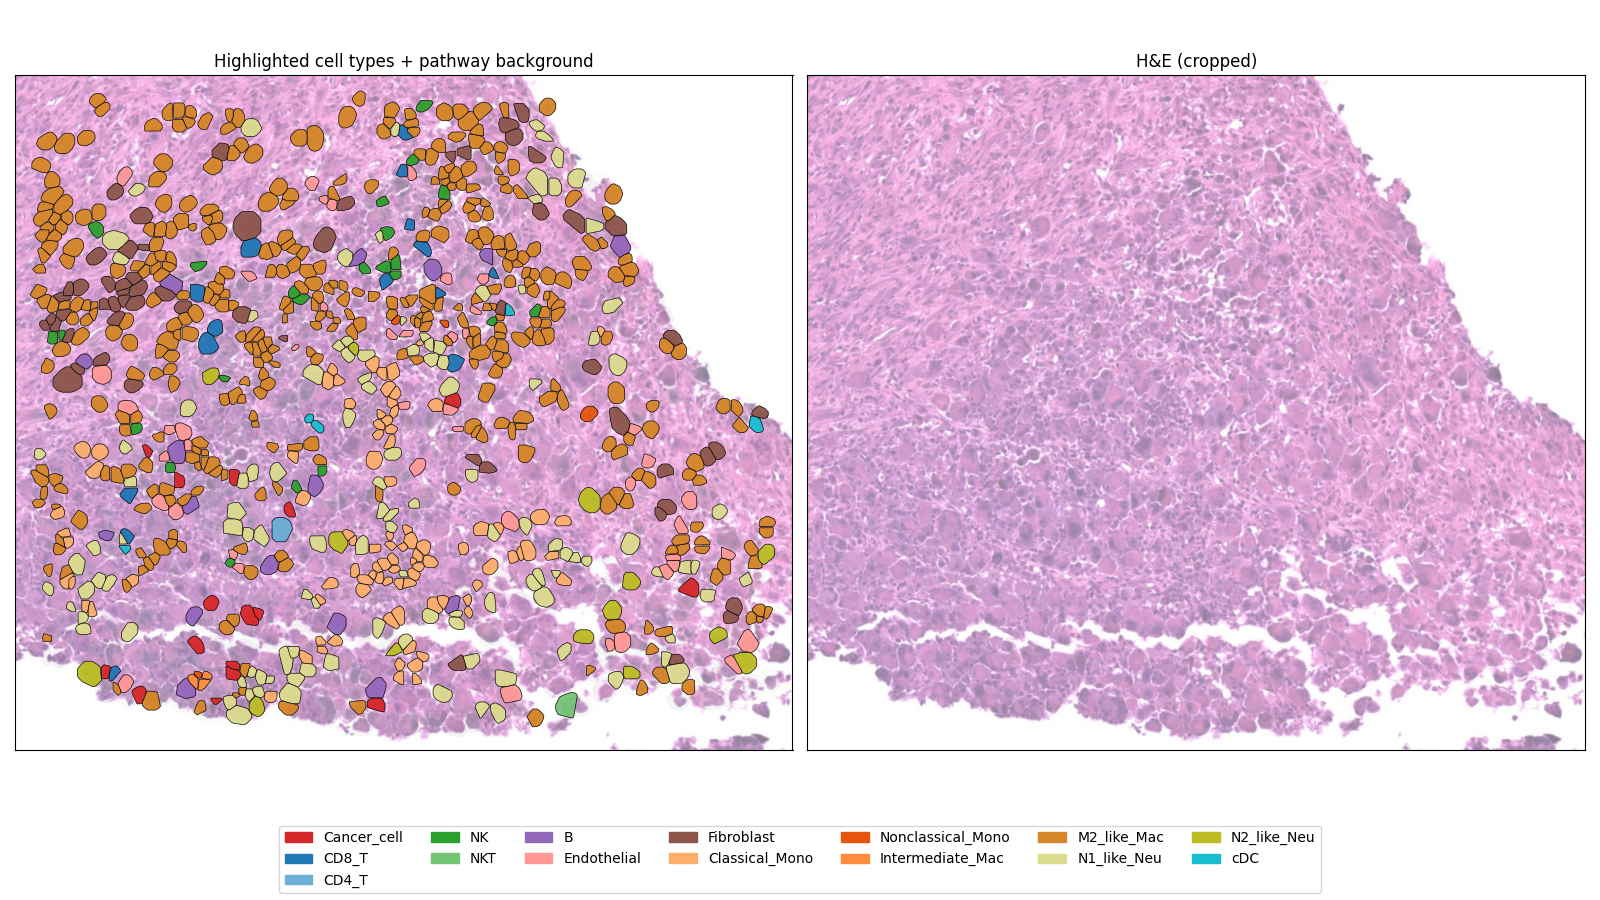

In [61]:
# ============================================================
# --- Parameters ---
# annotation_col       = "c2l_winner_spp1"
annotation_col       = "c2l_winner"
# cell_types_highlight = ["Spp1_Mac", "Cancer_cell", "N2_like_Neu"]#"N1_like_Neu"]#, 
# cell_types_highlight = ["Spp1_Mac", "Cancer_cell"]
cell_types_highlight = cells_types_list
pad                  = 25     # crop padding in shared coord units

# Background (non-highlighted) pathway cells
bg_alpha      = 0.05   # lower = more faded/hidden
bg_linewidth  = 0.3    # 0 = no edges (cleaner); increase for visible outlines
bg_edgecolor  = "black" #"none"
# ============================================================

import matplotlib.patches as mpatches

# Bounding box from selected cells
sel_coords = coords_shared[state["sel"]]
xmin, xmax = sel_coords[:, 0].min() - pad, sel_coords[:, 0].max() + pad
ymin, ymax = sel_coords[:, 1].min() - pad, sel_coords[:, 1].max() + pad

# Shapes in selected region with annotation
selected_obs  = a_sub.obs_names[state["sel"]]
shapes_region = shapes[shapes.index.isin(selected_obs)].copy()
shapes_region = shapes_region.join(adata_sel.obs[[annotation_col]], how="left")

# Split: highlighted vs background
is_highlight     = shapes_region[annotation_col].isin(cell_types_highlight)
shapes_highlight = shapes_region[is_highlight].copy()
bg_idx           = shapes_region.index[~is_highlight]

# Background split by which pathway they display (from dual-pathway cell in memory)
bg_primary   = shapes_primary[shapes_primary.index.isin(bg_idx)].copy()
bg_secondary = shapes_secondary[shapes_secondary.index.isin(bg_idx)].copy()

print(f"Highlighted : {len(shapes_highlight)} cells")
print(f"BG IFN      : {len(bg_primary)} cells")
print(f"BG Glyc     : {len(bg_secondary)} cells")

# --- Plot ---
fig, (axL, axR) = plt.subplots(1, 2, figsize=(16, 9))

for ax in (axL, axR):
    ax.imshow(img_rgb, extent=[tx, tx + w, ty + h, ty], origin="upper", alpha=he_alpha)
    ax.set_xlim(xmin, xmax); ax.set_ylim(ymax, ymin)
    ax.set_xticks([]); ax.set_yticks([])

# --- Left panel ---

# Background secondary (Glycolysis) — bottom layer
if not bg_secondary.empty:
    bg_secondary.plot(
        column=pathway_2, cmap=cmap_2, ax=axL,
        alpha=bg_alpha, edgecolor=bg_edgecolor, linewidth=bg_linewidth,
        legend=False,
    )

# Background primary (IFN) — over secondary
if not bg_primary.empty:
    bg_primary.plot(
        column=pathway_1, cmap=cmap_1, ax=axL,
        vmin=vmin_1, vmax=vmax_1,
        alpha=bg_alpha, edgecolor=bg_edgecolor, linewidth=bg_linewidth,
        legend=False,
    )

# Highlighted cell types — top layer
for cell_type in cell_types_highlight:
    sub = shapes_highlight[shapes_highlight[annotation_col] == cell_type]
    if len(sub) == 0:
        continue
    color = CELL_TYPE_COLORS.get(cell_type, "#999999")
    sub.plot(ax=axL, facecolor=color, edgecolor="black", linewidth=0.5, alpha=0.95, zorder=3)

axL.set_title("Highlighted cell types + pathway background", fontsize=12)

# --- Right panel: H&E only ---
axR.set_title("H&E (cropped)", fontsize=12)

# Legend — highlighted types only, those actually present
present = [ct for ct in cell_types_highlight
           if (shapes_highlight[annotation_col] == ct).any()]
handles = [mpatches.Patch(color=CELL_TYPE_COLORS.get(ct, "#999999"), label=ct)
           for ct in present]
fig.legend(
    handles=handles,
    loc="lower center",
    ncol=min(len(present), 7),
    bbox_to_anchor=(0.5, 0.0),
    frameon=True,
    fontsize=10,
)

plt.tight_layout()
fig.subplots_adjust(bottom=0.10)
plt.show()


In [18]:
plt.close("all")

In [62]:
adata_sel.obs['c2l_winner'].value_counts()

c2l_winner
Unknown              981
M2_like_Mac          413
N1_like_Neu          119
Erythrocyte          105
Classical_Mono        92
Fibroblast            60
Endothelial           45
NK                    23
B                     16
Cancer_cell           16
CD8_T                 15
N2_like_Neu           14
cDC                    5
Nonclassical_Mono      4
Intermediate_Mac       3
NKT                    1
CD4_T                  1
Name: count, dtype: int64

In [ ]:
# for cell_type in adata_sel.obs["c2l_label_perm"].unique():
    
#     print(ct_count)
# # for cell_type in ct_count:
# #     if ct_count < 2:
# #         print(f"Skipping {cell_type} — only {ct_count} cell(s)")
# #         continue



In [38]:
valid_cell_types

CategoricalIndex(['Unknown', 'Neutrophils', 'CAR_T_cell', 'Monocyte',
                  'Erythrocyte', 'Macrophage', 'NK_cell'],
                 categories=['CAR_T_cell', 'Endothelial', 'Erythrocyte', 'Fibroblast', ..., 'Monocyte', 'NK_cell', 'Neutrophils', 'Unknown'], ordered=False, dtype='category', name='c2l_label_perm')

In [34]:
valid_cell_types

Index([False], dtype='bool', name='c2l_label_perm')

## Over representation analysis

In [63]:
import gseapy as gp

databases = [
    "KEGG_2019_Mouse",
    "GO_Biological_Process_2023",
    "GO_Molecular_Function_2023",
]

# --- Removing low cell counts --- #
ct_counts = adata_sel.obs["c2l_winner"].value_counts()
valid_cell_types = ct_counts[ct_counts >= 2].index
adata_sel = adata_sel[adata_sel.obs["c2l_winner"].isin(valid_cell_types)]

sc.tl.rank_genes_groups(adata_sel, groupby="c2l_winner", method="wilcoxon")

ora_results = {}

for cell_type in adata_sel.obs["c2l_winner"].unique():
    

    markers = (
        sc.get.rank_genes_groups_df(adata_sel, group=cell_type)
        # .query("pvals_adj < 0.2 and logfoldchanges > 0.5")
        .query("pvals < 0.05 and logfoldchanges > 0.5")
        .head(200)["names"]
        .tolist()
    )

    if len(markers) < 3:
        print(f"Skipping {cell_type} — too few markers ({len(markers)})")
        continue

    print(f"Running ORA for {cell_type} ({len(markers)} markers)...")
    ora_results[cell_type] = gp.enrichr(
        gene_list=markers,
        gene_sets=databases,
        organism="mouse",
        outdir=None,
    ).results


/home/janzules/mamba_envs/spatial_gpu_py311/lib/python3.11/site-packages/anndata/_core/anndata.py:1190: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
... storing 'c2l_winner' as categorical
/home/janzules/mamba_envs/spatial_gpu_py311/lib/python3.11/site-packages/anndata/_core/anndata.py:1190: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
... storing 'c2l_runnerup' as categorical
/home/janzules/mamba_envs/spatial_gpu_py311/lib/python3.11/site-packages/anndata/_core/anndata.py:1190: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
... storing 'c2l_winner_spp1' as categorical


Running ORA for Unknown (200 markers)...
Running ORA for CD8_T (200 markers)...
Running ORA for M2_like_Mac (200 markers)...
Running ORA for Erythrocyte (200 markers)...
Running ORA for N1_like_Neu (190 markers)...
Running ORA for B (200 markers)...
Running ORA for NK (74 markers)...
Running ORA for Fibroblast (200 markers)...
Running ORA for Endothelial (114 markers)...
Running ORA for N2_like_Neu (200 markers)...
Running ORA for Classical_Mono (200 markers)...
Running ORA for Intermediate_Mac (61 markers)...
Running ORA for Cancer_cell (200 markers)...
Running ORA for cDC (65 markers)...
Running ORA for Nonclassical_Mono (60 markers)...


In [33]:

# Summary
for ct, df in ora_results.items():
    sig = df[df["Adjusted P-value"] < 0.05].sort_values("Adjusted P-value")
    print(f"\n=== {ct} ({len(sig)} significant terms) ===")
    print(sig[["Gene_set", "Term", "Overlap", "Adjusted P-value"]]
          .head(25).to_string(index=False))



=== N1_like_Neu (690 significant terms) ===
                  Gene_set                                                    Term Overlap  Adjusted P-value
           KEGG_2019_Mouse                                           Leishmaniasis   18/67      4.455133e-19
GO_Biological_Process_2023     Cellular Response To Cytokine Stimulus (GO:0071345)  31/308      5.716341e-19
GO_Biological_Process_2023 Positive Regulation Of Cytokine Production (GO:0001819)  30/320      1.106578e-17
GO_Biological_Process_2023        Cytokine-Mediated Signaling Pathway (GO:0019221)  27/257      3.666016e-17
GO_Biological_Process_2023    Cellular Response To Type II Interferon (GO:0071346)   16/66      1.086483e-15
GO_Biological_Process_2023             Response To Type II Interferon (GO:0034341)   17/80      1.086483e-15
           KEGG_2019_Mouse                                            Tuberculosis  21/178      7.285292e-15
           KEGG_2019_Mouse                              Osteoclast differentiation 

In [40]:
sc.get.rank_genes_groups_df(adata_sel, group="cDC").head(40)

,names,scores,logfoldchanges,pvals,pvals_adj
0,Cacnb3,6.648714,7.814676,2.956645e-11,5.625314e-07
1,Igfbp7,6.111124,5.506724,9.893176e-10,9.411379e-06
2,Cst3,5.344557,1.728049,9.063861e-08,5.748301e-04
3,Ccl5,4.380284,4.406297,1.185246e-05,5.281646e-02
4,Ccl22,4.345750,6.016805,1.388007e-05,5.281646e-02
5,Cnn2,4.291998,4.304598,1.770727e-05,5.614975e-02
6,Eng,4.235268,4.777330,2.282797e-05,6.204642e-02
7,Tmem123,4.170382,3.753088,3.040890e-05,7.231997e-02
8,Col4a1,4.036570,2.889556,5.423837e-05,1.146599e-01
9,Crip1,3.951900,3.903565,7.753314e-05,1.394904e-01


In [37]:
(
    sc.get.rank_genes_groups_df(adata_sel, group="M1_like_Mac")
    .query("pvals < 0.05 and logfoldchanges > 0.5")
    .head(200)["names"]
    .tolist()
)

['H2-Aa',
 'H2-Eb1',
 'Cd74',
 'H2-Ab1',
 'C1qa',
 'Tmsb4x',
 'Ctss',
 'C1qb',
 'Ucp2',
 'Cd52',
 'Aif1',
 'Ifi30',
 'Apoe',
 'Fcer1g',
 'Tyrobp',
 'Cxcl9',
 'Ccl5',
 'Lyz2',
 'Psap',
 'C3',
 'Ctsc',
 'Stat1',
 'Itm2b',
 'H2-K1',
 'Npc2',
 'Mpeg1',
 'Ly6a',
 'Unc93b1',
 'B2m',
 'Selenop',
 'Kctd12',
 'Gm2a',
 'Tapbp',
 'Cyba',
 'Fgl2',
 'Samhd1',
 'Pltp',
 'H2-DMa',
 'Pld4',
 'Rsrp1',
 'Ptprc',
 'Plbd1',
 'Itgb2',
 'C3ar1',
 'Sdc3',
 'Psmb8',
 'Themis2',
 'App',
 'Csf2ra',
 'Ccl8',
 'Arhgap30',
 'Cst3',
 'Tap1',
 'Alox5ap',
 'Srgn',
 'Cfb',
 'Adgre1',
 'Fcgr4',
 'Col1a2',
 'Ctsh',
 'Csf1r',
 'Efhd2',
 'H2-DMb1',
 'Sirpa',
 'Naaa',
 'Laptm5',
 'Marcks',
 'Lgals3bp',
 'Atox1',
 'Lst1',
 'Ptpn6',
 'Rarres2',
 'Cfp',
 'Ifi27l2a',
 'Fxyd5',
 'Serpina3g',
 'Psmb9',
 'Cxcl16',
 'Irf7',
 'Spi1',
 'Cpxm1',
 'Maf',
 'Ctsz',
 'Cybb',
 'C1qc',
 'Zbp1',
 'Ms4a6d',
 'Sfrp1',
 'Zeb2',
 'Arrb2',
 'Ly86',
 'Col1a1',
 'Fcgr3',
 'Il2rg',
 'Serping1',
 'Evl',
 'Fcgr2b',
 'Pdcd1lg2',
 'Bgn',
 'Clta',
 'P2r

### Pathway Visalization

In [62]:
adata_sel.obs['c2l_winner'].value_counts()

c2l_winner
Unknown              981
M2_like_Mac          413
N1_like_Neu          119
Erythrocyte          105
Classical_Mono        92
Fibroblast            60
Endothelial           45
NK                    23
B                     16
Cancer_cell           16
CD8_T                 15
N2_like_Neu           14
cDC                    5
Nonclassical_Mono      4
Intermediate_Mac       3
NKT                    1
CD4_T                  1
Name: count, dtype: int64

In [64]:
# ora_results['Classical_Mono'].head(60)
ora_results['Classical_Mono'].head(50)

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,KEGG_2019_Mouse,Leishmaniasis,18/67,2.801971e-21,4.735330e-19,0,0,39.865216,1886.580066,H2-EB1;ITGAM;ITGA4;NCF2;IFNGR1;STAT1;ITGB2;CYB...
1,KEGG_2019_Mouse,Phagosome,19/180,2.250275e-14,1.901482e-12,0,0,12.804674,402.388654,H2-T24;MSR1;H2-EB1;ITGAM;NCF2;H2-Q6;ITGB2;TAP1...
2,KEGG_2019_Mouse,Herpes simplex virus 1 infection,26/433,2.397145e-13,1.350392e-11,0,0,7.119913,206.899887,H2-T24;SP100;CCL12;H2-Q6;OAS1A;C3;IFIH1;CCL5;C...
3,KEGG_2019_Mouse,Influenza A,17/168,1.106708e-12,4.675839e-11,0,0,12.088192,332.783464,H2-EB1;CCL12;RSAD2;IFNGR1;STAT1;STAT2;OAS1A;H2...
4,KEGG_2019_Mouse,Epstein-Barr virus infection,19/229,1.771424e-12,5.987415e-11,0,0,9.792423,264.975497,LYN;H2-T24;H2-EB1;STAT1;STAT2;H2-Q6;OAS1A;TAP1...
5,KEGG_2019_Mouse,NOD-like receptor signaling pathway,18/205,2.673013e-12,6.870471e-11,0,0,10.372980,276.417249,GBP5;CCL12;IFI207;IFI204;STAT1;STAT2;PRKCD;OAS...
6,KEGG_2019_Mouse,Tuberculosis,17/178,2.845757e-12,6.870471e-11,0,0,11.331602,301.252824,CD74;H2-EB1;CEBPB;ITGAM;FCER1G;IFNGR1;STAT1;IT...
7,KEGG_2019_Mouse,Measles,14/144,1.995949e-10,4.216442e-09,0,0,11.388751,254.364695,STAT1;STAT2;MSN;OAS1A;FOS;IL2RG;IFIH1;CCND2;IL...
8,KEGG_2019_Mouse,Rheumatoid arthritis,11/84,7.457989e-10,1.400445e-08,0,0,15.727839,330.545160,CCL12;H2-EB1;IL1B;CCL5;ITGB2;ATP6V1B2;CCL2;FOS...
9,KEGG_2019_Mouse,Chemokine signaling pathway,15/197,1.386714e-09,2.343547e-08,0,0,8.739828,178.260400,LYN;CCL12;CXCL9;CCL11;STAT1;STAT2;PRKCD;ARRB2;...


### PathwaySelection

In [72]:
monocyte_tme_exclude = [
    # Pathogen/disease labels that are mechanistically redundant with IFN/MHC/myeloid activation
    "Leishmaniasis",
    "Epstein-Barr virus infection",
    "Tuberculosis",
    "Herpes simplex virus 1 infection",
    "Influenza A",
    "Viral myocarditis",
    "Staphylococcus aureus infection",
    "Rheumatoid arthritis",
    "Allograft rejection",
    "Graft-versus-host disease",
    "Type I diabetes mellitus",
    "Autoimmune thyroid disease",
    "Human immunodeficiency virus 1 infection",
    "Human T-cell leukemia virus 1 infection",
    "Toxoplasmosis",
    "Asthma",
    "Kaposi sarcoma-associated herpesvirus infection",
    "Measles",
    "Inflammatory bowel disease (IBD)",
    "Hepatitis C",
    "Human cytomegalovirus infection",
    "Intestinal immune network for IgA production",
    "AGE-RAGE signaling pathway in diabetic complications",
    "Systemic lupus erythematosus",
    "Pertussis",
    "Malaria",
    "Th1 and Th2 cell differentiation",
    "Human papillomavirus infection",
    "Primary immunodeficiency",
    "Th17 cell differentiation",
    "Acute myeloid leukemia",
    "Legionellosis",
    "Chagas disease (American trypanosomiasis)",
    "African trypanosomiasis",
    "Viral carcinogenesis",
    "Amoebiasis",
    "Hepatitis B",

    # Less useful / distracting for the main biological story
    "Transcriptional misregulation in cancer",
    "Prolactin signaling pathway",
    "Caffeine metabolism",
    "Type II diabetes mellitus",
    "Amyotrophic lateral sclerosis (ALS)",
    "Cellular senescence",
    "Platelet activation",
    "Pancreatic cancer",
    "Prion diseases",
    "Salivary secretion",
    "Collecting duct acid secretion",
    "Vasopressin-regulated water reabsorption",
]

monocyte_tumor_clearance_tme_include = [
    # Tumor-debris uptake / phagolysosomal clearance
    "Phagosome",
    "Lysosome",
    "Fc gamma R-mediated phagocytosis",
    "Complement and coagulation cascades",

    # Antigen presentation / cross-presentation-like machinery
    "Antigen processing and presentation",
    "Proteasome",
    "ABC transporters",

    # IFN / cytokine signaling
    "JAK-STAT signaling pathway",
    "Toll-like receptor signaling pathway",
    "NOD-like receptor signaling pathway",
    "RIG-I-like receptor signaling pathway",
    "Cytosolic DNA-sensing pathway",
    "TNF signaling pathway",

    # TME shaping / recruitment / trafficking
    "Chemokine signaling pathway",
    "Cytokine-cytokine receptor interaction",
    "Cell adhesion molecules (CAMs)",
    "Leukocyte transendothelial migration",
    "IL-17 signaling pathway",

    # Cell death / inflammatory cleanup
    "Apoptosis",
]

### Final Visualization

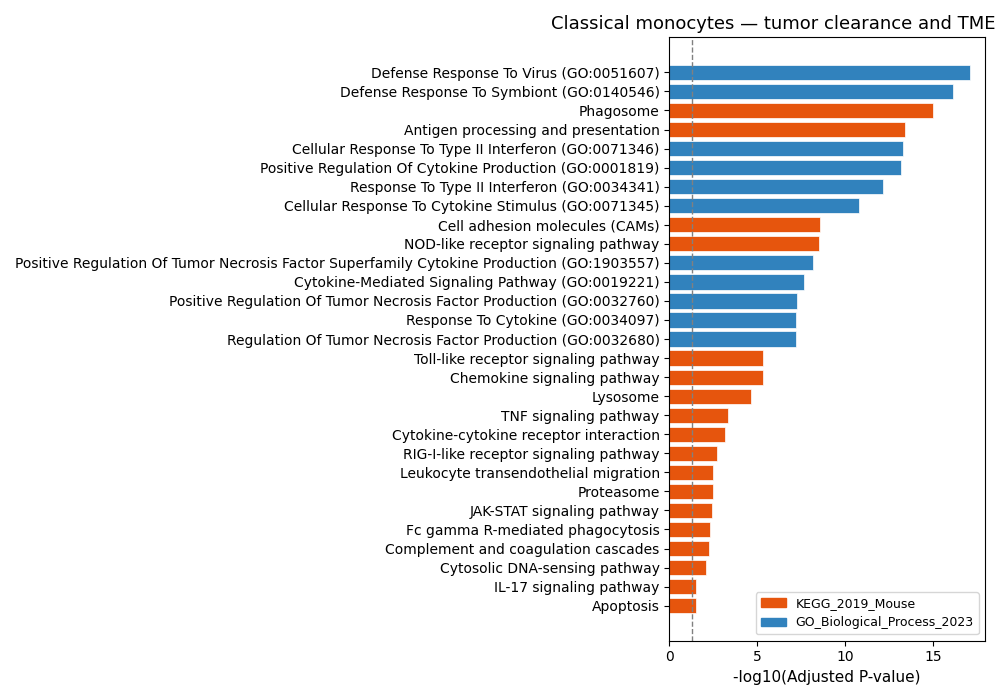

(<Figure size 1000x700 with 1 Axes>,
 <Axes: title={'center': 'Classical monocytes — tumor clearance and TME remodeling'}, xlabel='-log10(Adjusted P-value)'>)

In [73]:
# pathway_removal = ["Herpes simplex virus 1 infection", "Epstein-Barr virus infection", "Influenza A", ]

plot_ora_results(
    ora_results,
    cell_type="Classical_Mono",
    top_n=15,
    exclude=monocyte_tme_exclude,
    include=monocyte_tumor_clearance_tme_include,
    score_col="Adjusted P-value",
    figsize=(10, 7),
    title="Classical monocytes — tumor clearance and TME remodeling"
)

# Miscellaneous

## Metadata

In [20]:
list(sdata.images.keys())

['CyPSCA_1_1_hires_tissue_image',
 'CyPSCA_1_2_hires_tissue_image',
 'CyPSCA_2_4_hires_tissue_image',
 'CyT72_1_2_hires_tissue_image',
 'CyT72_1_4_hires_tissue_image',
 'CyT72_2_3_hires_tissue_image',
 'NoTx_1_4_hires_tissue_image',
 'NoTx_2_2_hires_tissue_image',
 'NoTx_2_4_hires_tissue_image',
 'RTCyPSCA_1_3_hires_tissue_image',
 'RTCyPSCA_1_4_hires_tissue_image',
 'RTCyPSCA_2_3_hires_tissue_image',
 'RTCyPSCA_2_4_hires_tissue_image',
 'RTCyT72_1_1_hires_tissue_image',
 'RTCyT72_2_1_hires_tissue_image',
 'RTCyT72_2_4_hires_tissue_image']

In [24]:
from spatialdata.transformations import get_transformation

for image_key in sdata.images:
    transforms = get_transformation(sdata.images[image_key], get_all=True)
    for cs, t in transforms.items():
        matrix = t.to_affine_matrix(input_axes=('x', 'y'), output_axes=('x', 'y'))
        x = matrix[0, 2]
        y = matrix[1, 2]
        print(f"{image_key} [{cs}]: x={x:.2f}, y={y:.2f}")
        

CyPSCA_1_1_hires_tissue_image [downscale_to_hires]: x=210.00, y=125.00
CyPSCA_1_2_hires_tissue_image [downscale_to_hires]: x=1205.00, y=304.00
CyPSCA_2_4_hires_tissue_image [downscale_to_hires]: x=3274.00, y=2978.00
CyT72_1_2_hires_tissue_image [downscale_to_hires]: x=156.00, y=582.00
CyT72_1_4_hires_tissue_image [downscale_to_hires]: x=858.00, y=2888.00
CyT72_2_3_hires_tissue_image [downscale_to_hires]: x=140.00, y=473.00
NoTx_1_4_hires_tissue_image [downscale_to_hires]: x=415.00, y=3031.00
NoTx_2_2_hires_tissue_image [downscale_to_hires]: x=299.00, y=2879.00
NoTx_2_4_hires_tissue_image [downscale_to_hires]: x=212.00, y=2729.00
RTCyPSCA_1_3_hires_tissue_image [downscale_to_hires]: x=2419.00, y=542.00
RTCyPSCA_1_4_hires_tissue_image [downscale_to_hires]: x=2909.00, y=218.00
RTCyPSCA_2_3_hires_tissue_image [downscale_to_hires]: x=2854.00, y=362.00
RTCyPSCA_2_4_hires_tissue_image [downscale_to_hires]: x=3116.00, y=1075.00
RTCyT72_1_1_hires_tissue_image [downscale_to_hires]: x=2739.00, y=

In [9]:
sdata.tables['segmentation_counts'].obsm['spatial'].shape

(425859, 2)